# Notebook 01: Data Exploration — EBM-NLP Dataset
## EMATM0067 Coursework | Task 2: Structured Information Extraction

This notebook explores the EBM-NLP dataset structure and builds
the core sentence-level dataframe used throughout the project.

**Output:** sentences_df.csv → saved to outputs/ folder
**Required:** EBM-NLP dataset in data/ebm_nlp_2_00/

In [32]:
import os

data_path = "../data/ebm_nlp_2_00"

print("Contents of data folder:")
for item in os.listdir(data_path):
    print(" ", item)

Contents of data folder:
  annotations
  documents


In [33]:
print(" DOCUMENTS folder:")
docs = os.listdir(data_path + "/documents")
print(f"Total files: {len(docs)}")
print("First 5 files:", docs[:5])

print("\n ANNOTATIONS folder:")
for item in os.listdir(data_path + "/annotations"):
    print(" ", item)

 DOCUMENTS folder:
Total files: 14979
First 5 files: ['10036953.pos', '10036953.tokens', '10036953.txt', '10037531.pos', '10037531.tokens']

 ANNOTATIONS folder:
  aggregated
  individual


In [34]:
print(" AGGREGATED folder:")
for item in os.listdir(data_path + "/annotations/aggregated"):
    print(" ", item)

 AGGREGATED folder:
  hierarchical_labels
  starting_spans


In [35]:
print(" HIERARCHICAL LABELS folder:")
for item in os.listdir(data_path + "/annotations/aggregated/hierarchical_labels"):
    print(" ", item)

 HIERARCHICAL LABELS folder:
  interventions
  outcomes
  participants


In [36]:
print(" PARTICIPANTS folder:")
participants_files = os.listdir(data_path + "/annotations/aggregated/hierarchical_labels/participants")
print(f"Total files: {len(participants_files)}")
print("First 5 files:", participants_files[:5])

 PARTICIPANTS folder:
Total files: 2
First 5 files: ['test', 'train']


In [37]:
print(" TRAIN folder:")
train_files = os.listdir(data_path + "/annotations/aggregated/hierarchical_labels/participants/train")
print(f"Total files: {len(train_files)}")
print("First 5 files:", train_files[:5])

 TRAIN folder:
Total files: 4609
First 5 files: ['10036953.AGGREGATED.ann', '10037531.AGGREGATED.ann', '10052279.AGGREGATED.ann', '10071998.AGGREGATED.ann', '10073522.AGGREGATED.ann']


In [38]:
# Let's read one annotation file and one text file to understand the format

# Read the text file (the actual abstract)
sample_id = "10036953"

with open(data_path + f"/documents/{sample_id}.txt", "r") as f:
    text = f.read()
    
print(" ABSTRACT TEXT:")
print(text)
print("\n" + "="*60)

# Read the annotation file (the PICO labels)
with open(data_path + f"/annotations/aggregated/hierarchical_labels/participants/train/{sample_id}.AGGREGATED.ann", "r") as f:
    ann = f.read()
    
print("\n PARTICIPANTS ANNOTATION:")
print(ann)

 ABSTRACT TEXT:
[Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections].

Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pylori infection. To evaluate the efficacy and safety of two 1-week low-dose triple-therapy drug regimens involving antisecretory drugs for Helicobacter pylori infection, 99 patients with H. pylori infection were treated with either lansoprazole (LPZ) or ranitidine (RNT) used together with clarithromycin (CAM) and metrinidazole (MTZ). The drug combination and administration periods in the PPI group were LPZ 30 mg, CAM 400 mg, MTZ 500 mg (LCM group). The ranitidine group received RNT 300 mg, CAM 400 mg, MTZ 500 mg (RCM group). The cure rate of H. pylori infection was 88% in the LCM group; 95% CI 79-97 and 92% in the RCM group; 95% CI 84-99.




 PARTICIPANTS ANNOTATION:
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
3
0
0
4
4

In [39]:
# Read the tokens file to see individual words
with open(data_path + f"/documents/{sample_id}.tokens", "r") as f:
    tokens = f.read().split("\n")

print(" TOKENS (words):")
print(tokens[:20])  # first 20 words
print(f"\nTotal tokens: {len(tokens)}")

 TOKENS (words):
['[', 'Triple', 'therapy', 'regimens', 'involving', 'H2', 'blockaders', 'for', 'therapy', 'of', 'Helicobacter', 'pylori', 'infections', ']', '.', 'Comparison', 'of', 'ranitidine', 'and', 'lansoprazole']

Total tokens: 162


In [40]:
# Read annotations
with open(data_path + f"/annotations/aggregated/hierarchical_labels/participants/train/{sample_id}.AGGREGATED.ann", "r") as f:
    ann_labels = f.read().strip().split("\n")

# Convert labels to integers
ann_labels = [int(x) for x in ann_labels]

print(" WORD  →  LABEL")
print("="*30)
for token, label in zip(tokens, ann_labels):
    if label != 0:  # only show labelled words
        print(f"  '{token}'  →  {label}  PARTICIPANT")

 WORD  →  LABEL
  '99'  →  3  PARTICIPANT
  'H.'  →  4  PARTICIPANT
  'pylori'  →  4  PARTICIPANT
  'infection'  →  4  PARTICIPANT


In [41]:
# Let's now see all PICO labels for the same abstract
pico_types = ["participants", "interventions", "outcomes"]

print(" WORD  →  PICO LABEL")
print("="*40)

for token_idx, token in enumerate(tokens):
    labels_for_token = {}
    
    for pico in pico_types:
        ann_path = data_path + f"/annotations/aggregated/hierarchical_labels/{pico}/train/{sample_id}.AGGREGATED.ann"
        
        # check if file exists
        if os.path.exists(ann_path):
            with open(ann_path, "r") as f:
                labels = [int(x) for x in f.read().strip().split("\n")]
            if token_idx < len(labels) and labels[token_idx] != 0:
                labels_for_token[pico] = labels[token_idx]
    
    if labels_for_token:
        print(f"  '{token}'  →  {labels_for_token}")

 WORD  →  PICO LABEL
  'H2'  →  {'interventions': 3}
  'blockaders'  →  {'interventions': 3}
  'Helicobacter'  →  {'outcomes': 1}
  'pylori'  →  {'outcomes': 1}
  'infections'  →  {'outcomes': 1}
  ']'  →  {'outcomes': 1}
  'Comparison'  →  {'outcomes': 6}
  'ranitidine'  →  {'interventions': 3}
  'lansoprazole'  →  {'interventions': 3}
  'efficacy'  →  {'outcomes': 6}
  'and'  →  {'outcomes': 6}
  'safety'  →  {'outcomes': 6}
  'antisecretory'  →  {'interventions': 3}
  'drugs'  →  {'interventions': 3}
  '99'  →  {'participants': 3}
  'H.'  →  {'participants': 4}
  'pylori'  →  {'participants': 4}
  'infection'  →  {'participants': 4}
  'lansoprazole'  →  {'interventions': 3}
  'ranitidine'  →  {'interventions': 3}
  'clarithromycin'  →  {'interventions': 3}
  '('  →  {'interventions': 3}
  'CAM'  →  {'interventions': 3}
  ')'  →  {'interventions': 3}
  'metrinidazole'  →  {'interventions': 3}
  '('  →  {'interventions': 3}
  'MTZ'  →  {'interventions': 3}
  ')'  →  {'interventions': 

In [42]:
data_path = "../data/ebm_nlp_2_00"
print(os.listdir(data_path))

['annotations', 'documents']


In [43]:
# DATA LOADER FUNCTION

def load_ebm_nlp_data(data_path, split="train", max_docs=500):
    """
    Loads EBM-NLP abstracts and their PICO labels.
    Returns a dataframe with sentences and their labels.
    """
    pico_types = ["participants", "interventions", "outcomes"]
    ann_base = data_path + f"/annotations/aggregated/hierarchical_labels/participants/{split}"
    doc_ids = [f.replace(".AGGREGATED.ann", "") for f in os.listdir(ann_base)]
    doc_ids = doc_ids[:max_docs]
    print(f"Loading {len(doc_ids)} documents...")
    rows = []
    for doc_id in doc_ids:
        token_path = data_path + f"/documents/{doc_id}.tokens"
        if not os.path.exists(token_path):
            continue
        with open(token_path, "r") as f:
            tokens = f.read().strip().split("\n")
        all_labels = {}
        for pico in pico_types:
            ann_path = data_path + f"/annotations/aggregated/hierarchical_labels/{pico}/{split}/{doc_id}.AGGREGATED.ann"
            if os.path.exists(ann_path):
                with open(ann_path, "r") as f:
                    labels = [int(x) for x in f.read().strip().split("\n")]
                all_labels[pico] = labels
        current_sentence = []
        current_labels = {pico: [] for pico in pico_types}
        for i, token in enumerate(tokens):
            current_sentence.append(token)
            for pico in pico_types:
                if pico in all_labels and i < len(all_labels[pico]):
                    current_labels[pico].append(all_labels[pico][i])
                else:
                    current_labels[pico].append(0)
            if token in [".", "?", "!"]:
                if len(current_sentence) > 3:
                    sentence_text = " ".join(current_sentence)
                    pico_counts = {}
                    for pico in pico_types:
                        pico_counts[pico] = sum(1 for l in current_labels[pico] if l != 0)
                    dominant_pico = max(pico_counts, key=pico_counts.get)
                    if pico_counts[dominant_pico] == 0:
                        dominant_pico = "none"
                    rows.append({
                        "doc_id": doc_id,
                        "sentence": sentence_text,
                        "label": dominant_pico,
                        "participants_count": pico_counts["participants"],
                        "interventions_count": pico_counts["interventions"],
                        "outcomes_count": pico_counts["outcomes"]
                    })
                current_sentence = []
                current_labels = {pico: [] for pico in pico_types}
    df = pd.DataFrame(rows)
    print(f" Loaded {len(df)} sentences from {len(doc_ids)} documents")
    return df

print(" load_ebm_nlp_data function defined!")

 load_ebm_nlp_data function defined!


In [44]:
import pandas as pd

df = load_ebm_nlp_data(data_path)
df.head(10)

Loading 500 documents...
 Loaded 5590 sentences from 500 documents


,doc_id,sentence,label,participants_count,interventions_count,outcomes_count
0,10036953,[ Triple therapy regimens involving H2 blockad...,outcomes,0,2,4
1,10036953,Comparison of ranitidine and lansoprazole in s...,interventions,0,2,1
2,10036953,To evaluate the efficacy and safety of two 1-w...,interventions,4,12,3
3,10036953,The drug combination and administration period...,interventions,0,3,0
4,10036953,"The ranitidine group received RNT 300 mg , CAM...",interventions,0,4,0
5,10036953,The cure rate of H. pylori infection was 88 % ...,outcomes,0,2,6
6,10037531,Xylitol for prevention of acute otitis media .,participants,4,1,0
7,10052279,Pre-operative short-term pulmonary rehabilitat...,interventions,0,10,0
8,10052279,The role of pre-operative short-term pulmonary...,interventions,0,4,0
9,10052279,Forty-five patients posted for coronary artery...,interventions,1,8,0


 LABEL DISTRIBUTION:
label
outcomes         2195
interventions    1406
none             1220
participants      769
Name: count, dtype: int64

Total sentences: 5590


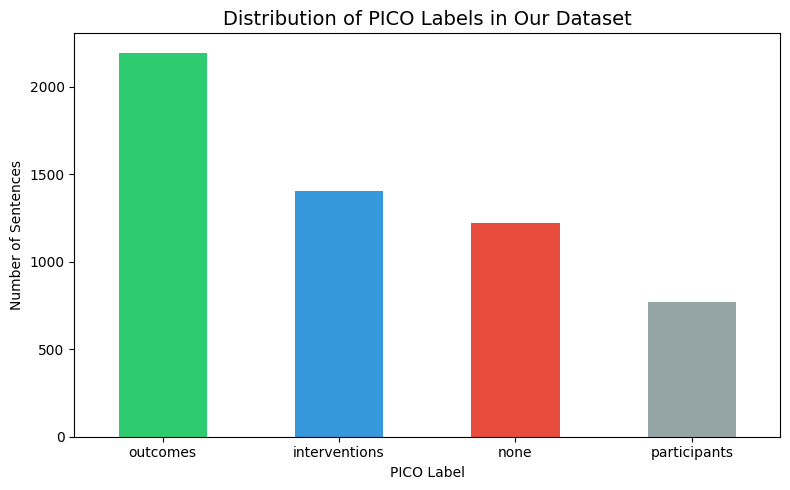


 Plot saved to outputs folder!


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of each label
print(" LABEL DISTRIBUTION:")
print(df["label"].value_counts())
print(f"\nTotal sentences: {len(df)}")

# Plot it
plt.figure(figsize=(8, 5))
df["label"].value_counts().plot(kind="bar", color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"])
plt.title("Distribution of PICO Labels in Our Dataset", fontsize=14)
plt.xlabel("PICO Label")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/label_distribution.png")
plt.show()

print("\n Plot saved to outputs folder!")

In [46]:
print(" EXAMPLE SENTENCES PER LABEL\n")

for label in ["participants", "interventions", "outcomes", "none"]:
    print(f"{'='*60}")
    print(f"  {label.upper()}")
    print(f"{'='*60}")
    examples = df[df["label"] == label]["sentence"].head(3).values
    for i, ex in enumerate(examples, 1):
        print(f"{i}. {ex[:150]}...")
    print()

 EXAMPLE SENTENCES PER LABEL

  PARTICIPANTS
1. Xylitol for prevention of acute otitis media ....
2. Anesthesia for in vitro fertilization : the addition of fentanyl to 1.5 % lidocaine ....
3. We assessed the effect of adding fentanyl to 1.5 % lidocaine in women undergoing ultrasonically guided oocyte retrieval ....

  INTERVENTIONS
1. Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pylori infection ....
2. To evaluate the efficacy and safety of two 1-week low-dose triple-therapy drug regimens involving antisecretory drugs for Helicobacter pylori infectio...
3. The drug combination and administration periods in the PPI group were LPZ 30 mg , CAM 400 mg , MTZ 500 mg ( LCM group ) ....

  OUTCOMES
1. [ Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections ] ....
2. The cure rate of H. pylori infection was 88 % in the LCM group ; 95 % CI 79-97 and 92 % in the RCM group ; 95 % CI 84-99 ....
3. Pre-oper

 AVERAGE SENTENCE LENGTH PER LABEL:
label
interventions    26.5
none             20.0
outcomes         28.4
participants     24.2
Name: sentence_length, dtype: float64


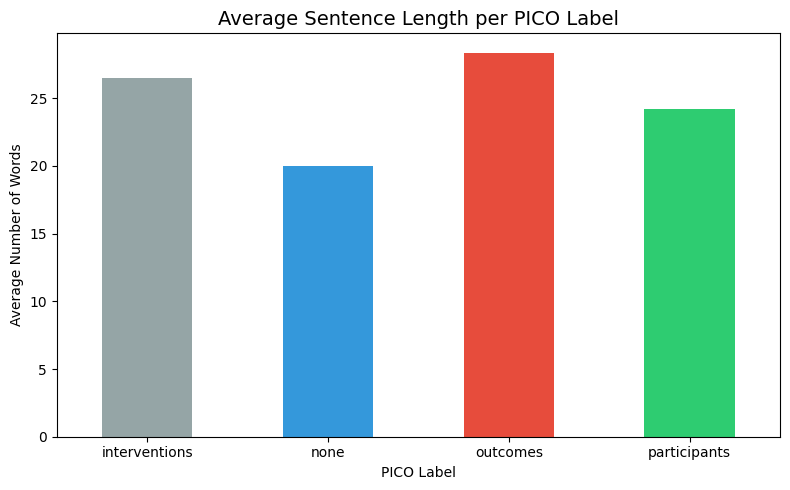

In [47]:
# Add sentence length column
df["sentence_length"] = df["sentence"].apply(lambda x: len(x.split()))

print(" AVERAGE SENTENCE LENGTH PER LABEL:")
print(df.groupby("label")["sentence_length"].mean().round(1))

# Plot
plt.figure(figsize=(8, 5))
df.groupby("label")["sentence_length"].mean().plot(
    kind="bar", 
    color=["#95a5a6", "#3498db", "#e74c3c", "#2ecc71"]
)
plt.title("Average Sentence Length per PICO Label", fontsize=14)
plt.xlabel("PICO Label")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/sentence_lengths.png")
plt.show()